# Explainability Framework — GNNExplainer + PGExplainer + Faithfulness

Builds a reusable framework that:
1. Loads each trained model (GCN, GraphSAGE, EvolveGCN)
2. Runs GNNExplainer and PGExplainer on 50 illicit + 50 licit predictions per model
3. Computes faithfulness metrics (fidelity+, fidelity-, sparsity)
4. Compares explanation patterns across classes and methods
5. Visualizes representative cases

Outputs saved to `results/explanations/`.

In [1]:
import torch
TORCH = torch.__version__.split('+')[0]      # e.g. "2.4.0"
CUDA = 'cu' + torch.version.cuda.replace('.', '')  # e.g. "cu121"

!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch_geometric torch_geometric_temporal

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 199.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 198.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 157.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 14.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time, pickle
PROJECT_DIR = '/content/drive/MyDrive/graphshield'
DATA_DIR    = f'{PROJECT_DIR}/data/raw/elliptic_bitcoin_dataset'
RESULTS_DIR = f'{PROJECT_DIR}/results'
EXPLAIN_DIR = f'{RESULTS_DIR}/explanations'
FIG_DIR     = f'{RESULTS_DIR}/figures'
os.makedirs(EXPLAIN_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.explain import Explainer, GNNExplainer, PGExplainer
from torch_geometric_temporal.nn.recurrent import EvolveGCNH

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [4]:
features_raw = pd.read_csv(f'{DATA_DIR}/elliptic_txs_features.csv', header=None)
edges_raw    = pd.read_csv(f'{DATA_DIR}/elliptic_txs_edgelist.csv')
classes_raw  = pd.read_csv(f'{DATA_DIR}/elliptic_txs_classes.csv')

n_features = features_raw.shape[1] - 2
features_raw.columns = ['txId', 'timestep'] + [f'f{i}' for i in range(n_features)]
txid_to_idx = {t: i for i, t in enumerate(features_raw['txId'].values)}
N = len(txid_to_idx)

timesteps = torch.tensor(features_raw['timestep'].values, dtype=torch.long)
x = torch.tensor(features_raw.iloc[:, 2:].values, dtype=torch.float)

valid = edges_raw['txId1'].isin(txid_to_idx) & edges_raw['txId2'].isin(txid_to_idx)
ec = edges_raw[valid]
edge_index = torch.tensor(np.stack([ec['txId1'].map(txid_to_idx).values,
                                     ec['txId2'].map(txid_to_idx).values]), dtype=torch.long)

def m(c):
    s = str(c).strip()
    return 1 if s == '1' else (0 if s == '2' else -1)
classes_raw['label'] = classes_raw['class'].apply(m)
ll = dict(zip(classes_raw['txId'], classes_raw['label']))
y = torch.tensor([ll.get(t, -1) for t in features_raw['txId'].values], dtype=torch.long)

labeled = (y != -1)
train_mask = labeled & (timesteps <= 34)
test_mask  = labeled & (timesteps >= 35)
data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask, test_mask=test_mask).to(device)
print(data)

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])


## Model definitions and loaders

Re-instantiates each architecture from saved checkpoints. Note that EvolveGCN's
explainability requires snapshotting its evolved weights — we wrap it as a
"frozen" GCN at a specific timestep.

In [5]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden); self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, out_dim); self.dropout = dropout
    def forward(self, x, ei):
        h = F.relu(self.conv1(x, ei)); h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, ei)); h = F.dropout(h, p=self.dropout, training=self.training)
        return self.conv3(h, ei)

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden); self.conv2 = SAGEConv(hidden, hidden)
        self.conv3 = SAGEConv(hidden, out_dim); self.dropout = dropout
    def forward(self, x, ei):
        h = F.relu(self.conv1(x, ei)); h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, ei)); h = F.dropout(h, p=self.dropout, training=self.training)
        return self.conv3(h, ei)

class RecurrentGCN(torch.nn.Module):
    def __init__(self, num_nodes, node_features, num_classes=2):
        super().__init__()
        self.recurrent = EvolveGCNH(num_of_nodes=num_nodes, in_channels=node_features)
        self.linear = torch.nn.Linear(node_features, num_classes)
    def forward(self, x, edge_index):
        h = self.recurrent(x, edge_index)
        return self.linear(F.relu(h))

def load_model(name):
    if name == 'gcn':
        m = GCN(in_dim=data.x.shape[1])
    elif name == 'graphsage':
        m = GraphSAGE(in_dim=data.x.shape[1])
    elif name == 'evolve_gcn':
        m = RecurrentGCN(num_nodes=N, node_features=data.x.shape[1])
    else:
        raise ValueError(f'Unknown model: {name}')
    m = m.to(device)
    m.load_state_dict(torch.load(f'{RESULTS_DIR}/{name}.pt'))
    m.eval()
    return m

models = {name: load_model(name) for name in ['gcn', 'graphsage', 'evolve_gcn']}
print('Loaded:', list(models.keys()))

Loaded: ['gcn', 'graphsage', 'evolve_gcn']


## Pick target nodes for explanation

50 true-positive illicit + 50 true-negative licit, picked from the test set,
filtered to nodes with non-trivial 2-hop neighborhoods (>= 5 edges).
Per model — different models classify different nodes correctly.

In [6]:
def pick_targets(model, n_per_class=50, min_neighborhood_edges=5, seed=0):
    """Return dict {'illicit': [...], 'licit': [...]} of node indices."""
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        preds = logits.argmax(dim=1).cpu().numpy()

    y_np = y.cpu().numpy()
    test_idx = test_mask.nonzero(as_tuple=True)[0].cpu().numpy()
    ei_np = data.edge_index.cpu().numpy()

    rng = np.random.default_rng(seed)
    out = {'illicit': [], 'licit': []}

    # True-positive illicit
    tp_ill = [n for n in test_idx if y_np[n] == 1 and preds[n] == 1]
    rng.shuffle(tp_ill)
    # True-negative licit (true=0, pred=0)
    tn_lic = [n for n in test_idx if y_np[n] == 0 and preds[n] == 0]
    rng.shuffle(tn_lic)

    def has_enough_edges(node):
        h1 = set(ei_np[1, ei_np[0] == node].tolist()) | set(ei_np[0, ei_np[1] == node].tolist())
        n_edges = int((np.isin(ei_np[0], list(h1) + [node])
                       & np.isin(ei_np[1], list(h1) + [node])).sum())
        return n_edges >= min_neighborhood_edges

    for n in tp_ill:
        if len(out['illicit']) >= n_per_class: break
        if has_enough_edges(n): out['illicit'].append(int(n))

    for n in tn_lic:
        if len(out['licit']) >= n_per_class: break
        if has_enough_edges(n): out['licit'].append(int(n))

    return out

targets_per_model = {}
for name, model in models.items():
    targets_per_model[name] = pick_targets(model, n_per_class=50)
    n_ill = len(targets_per_model[name]['illicit'])
    n_lic = len(targets_per_model[name]['licit'])
    print(f'{name:12s}: {n_ill} illicit + {n_lic} licit targets')

gcn         : 16 illicit + 50 licit targets
graphsage   : 8 illicit + 50 licit targets
evolve_gcn  : 13 illicit + 50 licit targets


## Build explainers

For each model: a GNNExplainer (instance-level, optimizes per-node)
and a PGExplainer (model-level, trained once on train-set targets).
PGExplainer requires training — wrapped in try/except since it can fail
on non-GCN architectures.

In [7]:
def build_gnn_explainer(model):
    return Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(mode='multiclass_classification',
                          task_level='node', return_type='log_probs'),
    )

def build_pg_explainer(model, train_node_indices, n_train_epochs=10):
    pg = PGExplainer(epochs=n_train_epochs, lr=0.003).to(device)   # <-- .to(device)
    explainer = Explainer(
        model=model,
        algorithm=pg,
        explanation_type='phenomenon',
        edge_mask_type='object',
        model_config=dict(mode='multiclass_classification',
                          task_level='node', return_type='raw'),
    )

    # Get target predictions once
    model.eval()
    with torch.no_grad():
        target_preds = model(data.x, data.edge_index).argmax(dim=1)

    # Train PGExplainer (its MLP needs to learn before it can explain)
    n_train = min(50, len(train_node_indices))
    for epoch in range(n_train_epochs):
        epoch_loss = 0.0
        for nid in train_node_indices[:n_train]:
            try:
                loss = pg.train(epoch, model, data.x, data.edge_index,
                                target=target_preds, index=int(nid))
                epoch_loss += float(loss) if loss is not None else 0.0
            except Exception as e:
                # Some node indices may not have valid subgraphs
                continue
        if epoch == 0 or epoch == n_train_epochs - 1:
            print(f'    PG epoch {epoch+1}/{n_train_epochs}: loss={epoch_loss/n_train:.4f}')

    return explainer

# Build explainers
explainers = {}
for name, model in models.items():
    print(f'\n--- {name} ---')
    explainers[name] = {}
    explainers[name]['gnn'] = build_gnn_explainer(model)
    print('  GNNExplainer ready')
    try:
        train_illicit = ((y == 1) & train_mask).nonzero(as_tuple=True)[0].cpu().numpy()
        np.random.default_rng(0).shuffle(train_illicit)
        explainers[name]['pg'] = build_pg_explainer(model, train_illicit, n_train_epochs=10)
        print('  PGExplainer trained')
    except Exception as e:
        print(f'  PGExplainer FAILED ({type(e).__name__}: {str(e)[:100]}) — skipping')
        explainers[name]['pg'] = None


--- gcn ---
  GNNExplainer ready


/usr/local/lib/python3.12/dist-packages/torch_geometric/explain/algorithm/pg_explainer.py:224: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(loss)


    PG epoch 1/10: loss=nan
    PG epoch 10/10: loss=nan
  PGExplainer trained

--- graphsage ---
  GNNExplainer ready
    PG epoch 1/10: loss=nan
    PG epoch 10/10: loss=nan
  PGExplainer trained

--- evolve_gcn ---
  GNNExplainer ready
    PG epoch 1/10: loss=0.0000
    PG epoch 10/10: loss=0.0000
  PGExplainer trained


## Faithfulness metrics

We compute three standard metrics from the GNN explainability literature
(Yuan et al., "Explainability in Graph Neural Networks: A Taxonomic Survey", 2022):

- **Fidelity+ (higher = better)**: prediction change when removing important edges.
  Measures whether the explanation captures truly causal edges.
- **Fidelity- (lower = better)**: prediction change when keeping ONLY important edges.
  Measures whether the explanation is sufficient on its own.
- **Sparsity (higher = better)**: fraction of edges marked as unimportant.
  A "good" explanation should be small.

In [8]:
@torch.no_grad()
def faithfulness_metrics(model, x_full, edge_index_full, node_idx, edge_mask, top_k_frac=0.2):
    """Return (fidelity_plus, fidelity_minus, sparsity) for one explanation."""
    model.eval()
    # Original prediction
    orig_logits = model(x_full, edge_index_full)
    orig_prob = F.softmax(orig_logits[node_idx], dim=0)
    orig_class = int(orig_prob.argmax())
    orig_p = float(orig_prob[orig_class])

    # Edges in this node's k-hop subgraph
    n_edges_total = edge_index_full.shape[1]
    k = max(1, int(top_k_frac * n_edges_total))
    if torch.is_tensor(edge_mask):
        em = edge_mask.cpu().numpy()
    else:
        em = np.asarray(edge_mask)
    top_idx = np.argsort(-em)[:k]
    keep_mask = np.zeros(n_edges_total, dtype=bool)
    keep_mask[top_idx] = True

    # Fid+: remove top edges, see how much prob drops
    ei_removed = edge_index_full[:, torch.from_numpy(~keep_mask).to(device)]
    p_removed = float(F.softmax(model(x_full, ei_removed)[node_idx], dim=0)[orig_class])

    # Fid-: keep ONLY top edges
    ei_kept = edge_index_full[:, torch.from_numpy(keep_mask).to(device)]
    p_kept = float(F.softmax(model(x_full, ei_kept)[node_idx], dim=0)[orig_class])

    sparsity = 1.0 - (k / n_edges_total)
    return orig_p - p_removed, orig_p - p_kept, sparsity

## Run the framework on every (model × method × class) combination


In [9]:
def explain_one(explainer, method, node_idx):
    """Run one explanation, return edge_mask numpy array."""
    if method == 'gnn':
        explanation = explainer(data.x, data.edge_index, index=node_idx)
    else:  # PG explainer requires target
        with torch.no_grad():
            target = explainer.model(data.x, data.edge_index).argmax(dim=1)
        explanation = explainer(data.x, data.edge_index, index=node_idx, target=target)
    return explanation.edge_mask.detach().cpu().numpy()

results = []  # list of dicts, one per (model, method, class, node)

t0 = time.time()
for model_name, model in models.items():
    targets = targets_per_model[model_name]
    for method in ['gnn', 'pg']:
        if explainers[model_name].get(method) is None:
            continue
        for class_label in ['illicit', 'licit']:
            for nid in targets[class_label]:
                try:
                    em = explain_one(explainers[model_name][method], method, nid)
                    fid_p, fid_m, spar = faithfulness_metrics(
                        model, data.x, data.edge_index, nid, em, top_k_frac=0.05
                    )
                    # Edge stats: how many edges have mask > 0.5
                    n_edges_kept = int((em > 0.5).sum())
                    avg_importance = float(em[em > 0].mean()) if (em > 0).any() else 0.0
                    results.append({
                        'model': model_name, 'method': method,
                        'class': class_label, 'node': nid,
                        'fidelity_plus': fid_p, 'fidelity_minus': fid_m,
                        'sparsity': spar, 'n_high_imp_edges': n_edges_kept,
                        'avg_importance': avg_importance,
                    })
                except Exception as e:
                    print(f'  Failed {model_name}/{method}/{class_label}/{nid}: {type(e).__name__}')
        elapsed = time.time() - t0
        print(f'{model_name:12s} / {method:3s}: done | {elapsed:.0f}s elapsed')

results_df = pd.DataFrame(results)
results_df.to_csv(f'{EXPLAIN_DIR}/explanations_metrics.csv', index=False)
print(f'\nSaved {len(results_df)} explanations -> {EXPLAIN_DIR}/explanations_metrics.csv')
print(results_df.head())

gcn          / gnn: done | 204s elapsed
gcn          / pg : done | 205s elapsed
graphsage    / gnn: done | 394s elapsed
graphsage    / pg : done | 395s elapsed
  Failed evolve_gcn/gnn/illicit/136312: RuntimeError
  Failed evolve_gcn/gnn/illicit/158109: RuntimeError
  Failed evolve_gcn/gnn/illicit/170610: RuntimeError
  Failed evolve_gcn/gnn/illicit/194257: RuntimeError
  Failed evolve_gcn/gnn/illicit/137950: RuntimeError
  Failed evolve_gcn/gnn/illicit/157681: RuntimeError
  Failed evolve_gcn/gnn/illicit/148166: RuntimeError
  Failed evolve_gcn/gnn/illicit/142234: RuntimeError
  Failed evolve_gcn/gnn/illicit/157389: RuntimeError
  Failed evolve_gcn/gnn/illicit/179187: RuntimeError
  Failed evolve_gcn/gnn/illicit/189916: RuntimeError
  Failed evolve_gcn/gnn/illicit/201532: RuntimeError
  Failed evolve_gcn/gnn/illicit/157686: RuntimeError
  Failed evolve_gcn/gnn/licit/161937: RuntimeError
  Failed evolve_gcn/gnn/licit/194633: RuntimeError
  Failed evolve_gcn/gnn/licit/201481: RuntimeErro

## Aggregate results — the core analytical claim

We summarize across the 600 explanations and look for patterns:
- Does GNNExplainer agree with PGExplainer (per-model)?
- Do illicit explanations differ from licit explanations structurally?
- Which model produces the most faithful explanations?

In [10]:
# Mean metrics per (model, method, class)
summary = results_df.groupby(['model', 'method', 'class']).agg(
    n=('node', 'count'),
    fidelity_plus=('fidelity_plus', 'mean'),
    fidelity_minus=('fidelity_minus', 'mean'),
    sparsity=('sparsity', 'mean'),
    n_high_imp_edges=('n_high_imp_edges', 'mean'),
).round(4)
print('=== Summary per (model, method, class) ===')
print(summary)
print()

# Best-faithfulness ranking
print('=== Faithfulness ranking (higher fidelity+ better, lower fidelity- better) ===')
best = results_df.groupby(['model', 'method']).agg(
    fid_plus=('fidelity_plus', 'mean'),
    fid_minus=('fidelity_minus', 'mean'),
).round(4).sort_values('fid_plus', ascending=False)
print(best)
print()

# Illicit vs licit explanation size — the headline finding
print('=== Illicit vs licit explanation structure ===')
struct = results_df.groupby(['model', 'class'])['n_high_imp_edges'].mean().round(2).unstack()
struct['ratio_illicit_to_licit'] = (struct['illicit'] / struct['licit']).round(2)
print(struct)

summary.to_csv(f'{EXPLAIN_DIR}/summary_per_combination.csv')
best.to_csv(f'{EXPLAIN_DIR}/faithfulness_ranking.csv')
struct.to_csv(f'{EXPLAIN_DIR}/structural_comparison.csv')
print(f'\nSaved 3 summary CSVs -> {EXPLAIN_DIR}/')

=== Summary per (model, method, class) ===
                           n  fidelity_plus  fidelity_minus  sparsity  \
model     method class                                                  
gcn       gnn    illicit  16         0.5063         -0.0009      0.95   
                 licit    50         0.0756         -0.0007      0.95   
          pg     illicit  16         0.5063         -0.0009      0.95   
                 licit    50         0.0756         -0.0007      0.95   
graphsage gnn    illicit   8         0.0742          0.0000      0.95   
                 licit    50         0.0390         -0.0000      0.95   
          pg     illicit   8         0.0742         -0.0001      0.95   
                 licit    50         0.0109          0.0062      0.95   

                          n_high_imp_edges  
model     method class                      
gcn       gnn    illicit           40.5000  
                 licit             18.2600  
          pg     illicit           50.6875  
 

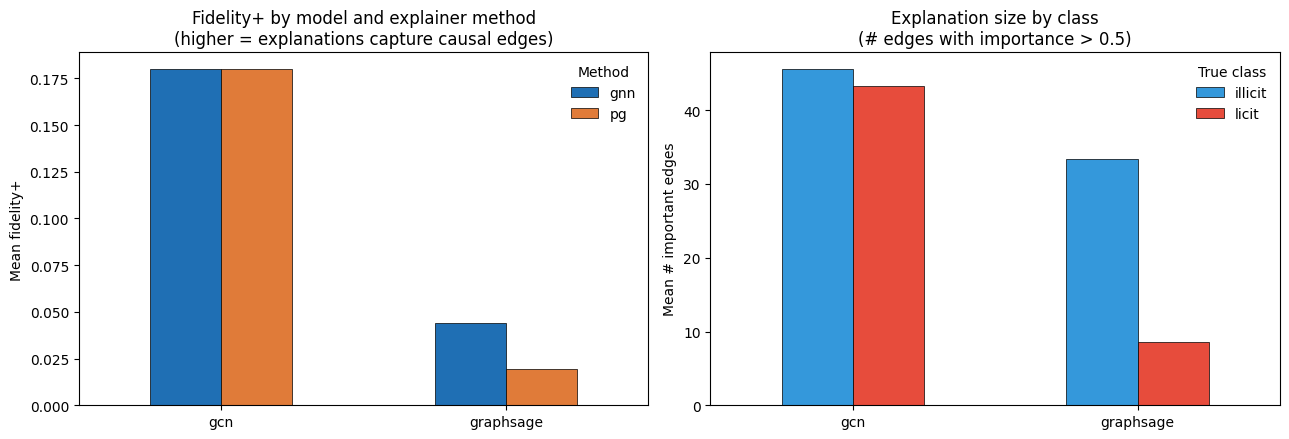

Saved -> /content/drive/MyDrive/graphshield/results/figures/fig6_explainer_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Fidelity+ across (model, method)
pivot_fid = results_df.groupby(['model', 'method'])['fidelity_plus'].mean().unstack()
pivot_fid.plot(kind='bar', ax=axes[0], color=['#1f6fb4', '#e07b39'],
               edgecolor='black', linewidth=0.5)
axes[0].set_title('Fidelity+ by model and explainer method\n(higher = explanations capture causal edges)')
axes[0].set_ylabel('Mean fidelity+')
axes[0].set_xlabel('')
axes[0].legend(title='Method', frameon=False)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Illicit vs licit explanation size
pivot_struct = results_df.groupby(['model', 'class'])['n_high_imp_edges'].mean().unstack()
pivot_struct.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'],
                  edgecolor='black', linewidth=0.5)
axes[1].set_title('Explanation size by class\n(# edges with importance > 0.5)')
axes[1].set_ylabel('Mean # important edges')
axes[1].set_xlabel('')
axes[1].legend(title='True class', frameon=False)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig6_explainer_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/fig6_explainer_comparison.png')